In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
years = range(2013, 2024)
dfs = []

for year in years:
    temp = pd.read_csv(f"PROV_TYPE_{year}.csv")
    temp['Year'] = year
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

In [6]:
payments_per_year = (
    df.groupby('Year')['Tot_Mdcr_Pymt_Amt']
      .sum()
      .sort_index()
)

In [7]:
inflation_rate = payments_per_year.pct_change() * 100

print(inflation_rate)

Year
2013          NaN
2014     1.868940
2015     3.047234
2016     2.327773
2017     2.249003
2018     3.472307
2019     4.402786
2020    -7.932827
2021    12.119957
2022    -2.086864
2023     5.497878
Name: Tot_Mdcr_Pymt_Amt, dtype: float64


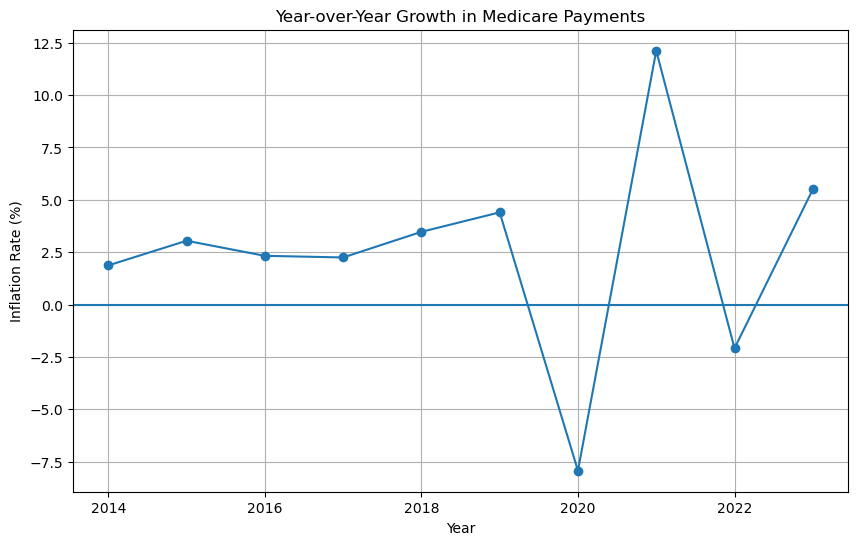

In [8]:
plt.figure(figsize=(10,6))

plt.plot(inflation_rate.index,
         inflation_rate.values,
         marker='o')

plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.title("Year-over-Year Growth in Medicare Payments")
plt.axhline(0)
plt.grid(True)

plt.show()